In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Logistic Regression Model

In [5]:
df=pd.read_csv('Customer Churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0     7590-VHVEG  Female              0  ...          29.85        29.85     No
1     5575-GNVDE    Male              0  ...          56.95       1889.5     No
2     3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3     7795-CFOCW    Male              0  ...          42.30      1840.75     No
4     9237-HQITU  Female              0  ...          70.70       151.65    Yes
...          ...     ...            ...  ...            ...          ...    ...
7038  6840-RESVB    Male              0  ...          84.80       1990.5     No
7039  2234-XADUH  Female              0  ...         103.20       7362.9     No
7040  4801-JZAZL  Female              0  ...          29.60       346.45     No
7041  8361-LTMKD    Male              1  ...          74.40        306.6    Yes
7042  3186-AJIEK    Male              0  ...         105.65       6844.5     No

[7043

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df = df.drop(columns=['customerID', 'gender', 'PhoneService', 'MultipleLines'])


In [11]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [14]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df['Churn']=le.fit_transform(df['Churn'])

In [16]:
binary_cols = [
    'Partner', 'Dependents', 'PaperlessBilling',
    
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [17]:
df=pd.get_dummies(df,columns=['Contract', 'PaymentMethod', 'InternetService'],drop_first=True)

In [18]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,2,0,0,0,0,1,29.85,29.85,0,False,False,False,True,False,False,False
1,0,0,0,34,2,0,2,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False
2,0,0,0,2,2,2,0,0,0,0,1,53.85,108.15,1,False,False,False,False,True,False,False
3,0,0,0,45,2,0,2,2,0,0,0,42.30,1840.75,0,True,False,False,False,False,False,False
4,0,0,0,2,0,0,0,0,0,0,1,70.70,151.65,1,False,False,False,True,False,True,False


In [19]:
df=df.dropna()
X = df.drop('Churn', axis=1)
y = df['Churn']


In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

C:\Users\raghv\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(2110,))

In [23]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,y_pred)
acc

0.7928909952606635

In [24]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

[[1375  174]
 [ 263  298]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1549
           1       0.63      0.53      0.58       561

    accuracy                           0.79      2110
   macro avg       0.74      0.71      0.72      2110
weighted avg       0.78      0.79      0.79      2110

ROC-AUC: 0.7094318800353054


In [25]:
# probability of churn
y_prob=model.predict_proba(X_test)[:,1]
y_prob

array([0.00924737, 0.11177383, 0.68511308, ..., 0.01587339, 0.27764233,
       0.21427652], shape=(2110,))

In [26]:
from sklearn.model_selection import GridSearchCV


In [27]:
param_grid={
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

In [28]:
grid=GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
)

In [29]:
grid.fit(X_train,y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear']}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [30]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.5436138165014185


In [31]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.79      2110

0.7928909952606635
ROC-AUC: 0.8307452683520736


In [1]:
# K Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [33]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
y_pred2=knn.predict(X_train)
y_pred2

array([0, 0, 0, ..., 0, 0, 1], shape=(4922,))

In [36]:
print(classification_report(y_train, y_pred2))
print(accuracy_score(y_train, y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      3614
           1       0.73      0.57      0.64      1308

    accuracy                           0.83      4922
   macro avg       0.79      0.75      0.76      4922
weighted avg       0.82      0.83      0.82      4922

0.829134498171475


In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [38]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [39]:
param_grid={
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [40]:
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [42]:
grid.fit(X_train_scaled,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,15


In [43]:
print("Best Params:",grid.best_params_)
print("Best Accuracy Score:",grid.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best Accuracy Score: 0.5703723202012225


In [44]:
best_knn=grid.best_estimator_

In [45]:
y_pred_bestKnn = best_knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.79      2110



In [47]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred_rf=rf.predict(X_test)
y_prob_rf=rf.predict_proba(X_test)[:,1]

In [52]:
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.61      0.47      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110

ROC-AUC: 0.811459063348328


In [53]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [54]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

In [55]:
y_pred_bestrf=best_rf.predict(X_test)
y_prob_bestrf=best_rf.predict_proba(X_test)[:,1]

In [56]:
print(classification_report(y_test, y_pred_bestrf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bestrf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1549
           1       0.65      0.50      0.56       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.71      2110
weighted avg       0.78      0.79      0.79      2110

ROC-AUC: 0.8344248316146694


In [57]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada=AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train,y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [58]:
y_pred_ada=ada.predict(X_test)
y_proba_ada=ada.predict_proba(X_test)[:,1]

In [59]:
print(classification_report(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_ada))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.65      0.52      0.58       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.72      2110
weighted avg       0.79      0.80      0.79      2110

ROC-AUC: 0.8425112400732345


In [60]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

In [61]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    random_state=42
)

grid = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_ada = grid.best_estimator_


In [62]:
y_pred_bestada = best_ada.predict(X_test)
y_proba_bestada = best_ada.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.79      2110

ROC-AUC: 0.8307452683520736


In [63]:
# Stacking Classifier

from sklearn.ensemble import StackingClassifier


In [64]:
base_estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance')),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )),
    ('ada', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        random_state=42
    ))
]


In [65]:
meta_model=LogisticRegression(max_iter=1000)

In [66]:
stack_clf=StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5
)

In [67]:
stack_clf.fit(X_train,y_train)

,estimators,"[('knn', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30


In [69]:
y_pred_stackclf = stack_clf.predict(X_test)
y_proba_stackclf = stack_clf.predict_proba(X_test)[:, 1]


In [70]:
print(classification_report(y_test, y_pred_stackclf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_stackclf))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1549
           1       0.67      0.47      0.56       561

    accuracy                           0.80      2110
   macro avg       0.75      0.70      0.71      2110
weighted avg       0.79      0.80      0.79      2110

ROC-AUC: 0.8394145380436346


In [72]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

results = []

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Evaluate models
evaluate_model('Logistic Regression', model, X_test, y_test)
evaluate_model('KNN', best_knn, X_test_scaled, y_test)
evaluate_model('Random Forest', best_rf, X_test, y_test)
evaluate_model('AdaBoost', best_ada, X_test, y_test)
evaluate_model('Stacking Classifier', stack_clf, X_test, y_test)

# Create DataFrame
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.792891,0.531194,0.576960,0.830745
1,KNN,0.780095,0.531194,0.562264,0.810494
2,Random Forest,0.794787,0.495544,0.562184,0.834425
3,AdaBoost,0.799052,0.515152,0.576846,0.842648
4,Stacking Classifier,0.798578,0.474153,0.555904,0.839415


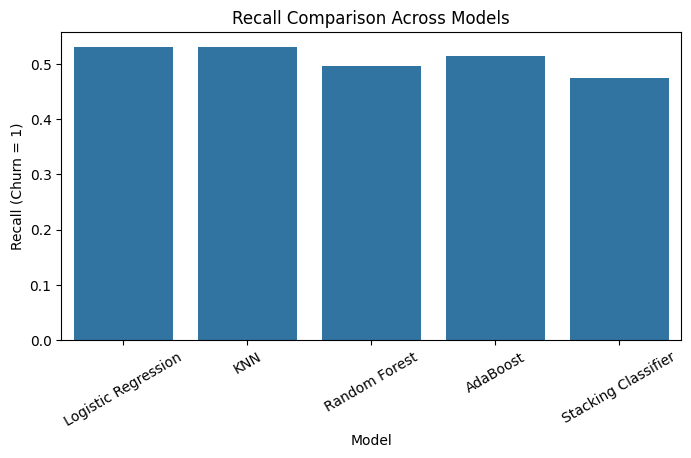

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(x='Model', y='Recall', data=results_df)
plt.xticks(rotation=30)
plt.title('Recall Comparison Across Models')
plt.ylabel('Recall (Churn = 1)')
plt.xlabel('Model')
plt.show()
